# Crop Disease Detection using MobileNetV2
**Transfer Learning | Deep Learning | Computer Vision**

This project uses **MobileNetV2** (pre-trained on ImageNet) with **transfer learning** and **fine-tuning** to classify **tomato plant diseases** from leaf images.

**Dataset:** [PlantVillage Dataset](https://www.kaggle.com/datasets/emmarex/plantdisease) (Kaggle)

**Pipeline:**
1. Data Download & Preprocessing
2. Exploratory Data Analysis (EDA)
3. Data Augmentation
4. Transfer Learning with MobileNetV2
5. Fine-Tuning
6. Evaluation (Accuracy, Loss, Confusion Matrix, Classification Report)
7. GradCAM Visualization
8. Single Image Prediction


## 1. Install Dependencies & Import Libraries

In [2]:
!pip install -q tensorflow numpy matplotlib seaborn scikit-learn split-folders

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

import matplotlib.pyplot as plt
import matplotlib.cm as cm_plt
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import os, shutil, json

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')


TensorFlow version: 2.20.0
GPU available: True


## 2. Download Dataset from Kaggle
> Upload your `kaggle.json` API token when prompted.

In [3]:
from google.colab import files
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d emmarex/plantdisease
!unzip -q plantdisease.zip -d plant_disease
print('Dataset downloaded and extracted!')


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown
100% 658M/658M [00:05<00:00, 133MB/s] 

Dataset downloaded and extracted!


## 3. Filter Tomato Disease Classes

In [4]:
source_dir = 'plant_disease/PlantVillage'
dest_dir   = 'tomato_dataset_filtered'
os.makedirs(dest_dir, exist_ok=True)

for class_folder in os.listdir(source_dir):
    if class_folder.startswith('Tomato'):
        src = os.path.join(source_dir, class_folder)
        dst = os.path.join(dest_dir, class_folder)
        if not os.path.exists(dst):
            shutil.copytree(src, dst)
            print(f'  Copied: {class_folder}')

classes = sorted(os.listdir(dest_dir))
print(f'\nTotal classes: {len(classes)}')
for c in classes:
    count = len(os.listdir(os.path.join(dest_dir, c)))
    print(f'  {c}: {count} images')


  Copied: Tomato_Leaf_Mold
  Copied: Tomato_healthy
  Copied: Tomato_Bacterial_spot
  Copied: Tomato__Target_Spot
  Copied: Tomato_Septoria_leaf_spot
  Copied: Tomato__Tomato_mosaic_virus
  Copied: Tomato_Late_blight
  Copied: Tomato_Spider_mites_Two_spotted_spider_mite
  Copied: Tomato_Early_blight
  Copied: Tomato__Tomato_YellowLeaf__Curl_Virus

Total classes: 10
  Tomato_Bacterial_spot: 2127 images
  Tomato_Early_blight: 1000 images
  Tomato_Late_blight: 1909 images
  Tomato_Leaf_Mold: 952 images
  Tomato_Septoria_leaf_spot: 1771 images
  Tomato_Spider_mites_Two_spotted_spider_mite: 1676 images
  Tomato__Target_Spot: 1404 images
  Tomato__Tomato_YellowLeaf__Curl_Virus: 3209 images
  Tomato__Tomato_mosaic_virus: 373 images
  Tomato_healthy: 1591 images


## 4. Exploratory Data Analysis (EDA)

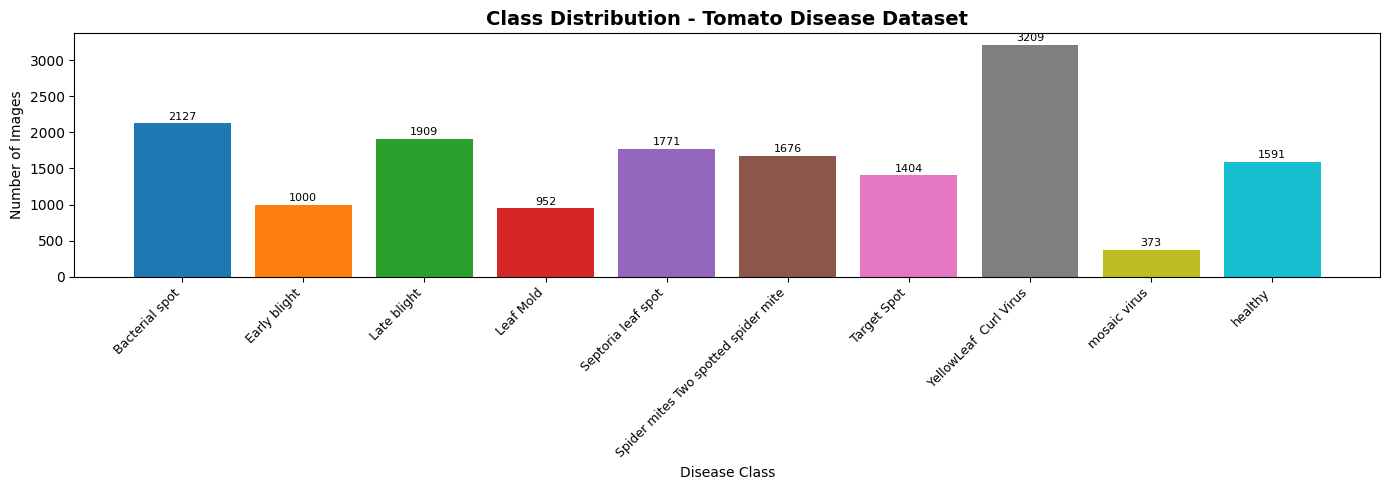

Total images: 16012


In [5]:
class_counts = {}
for c in sorted(os.listdir(dest_dir)):
    p = os.path.join(dest_dir, c)
    if os.path.isdir(p):
        class_counts[c] = len(os.listdir(p))

display_names = [k.replace('Tomato__','').replace('Tomato_','').replace('_',' ') for k in class_counts]

plt.figure(figsize=(14, 5))
bars = plt.bar(display_names, class_counts.values(),
               color=plt.cm.tab10.colors[:len(class_counts)])
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.title('Class Distribution - Tomato Disease Dataset', fontsize=14, fontweight='bold')
plt.xlabel('Disease Class'); plt.ylabel('Number of Images')
for bar, cnt in zip(bars, class_counts.values()):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
             str(cnt), ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()
print(f'Total images: {sum(class_counts.values())}')


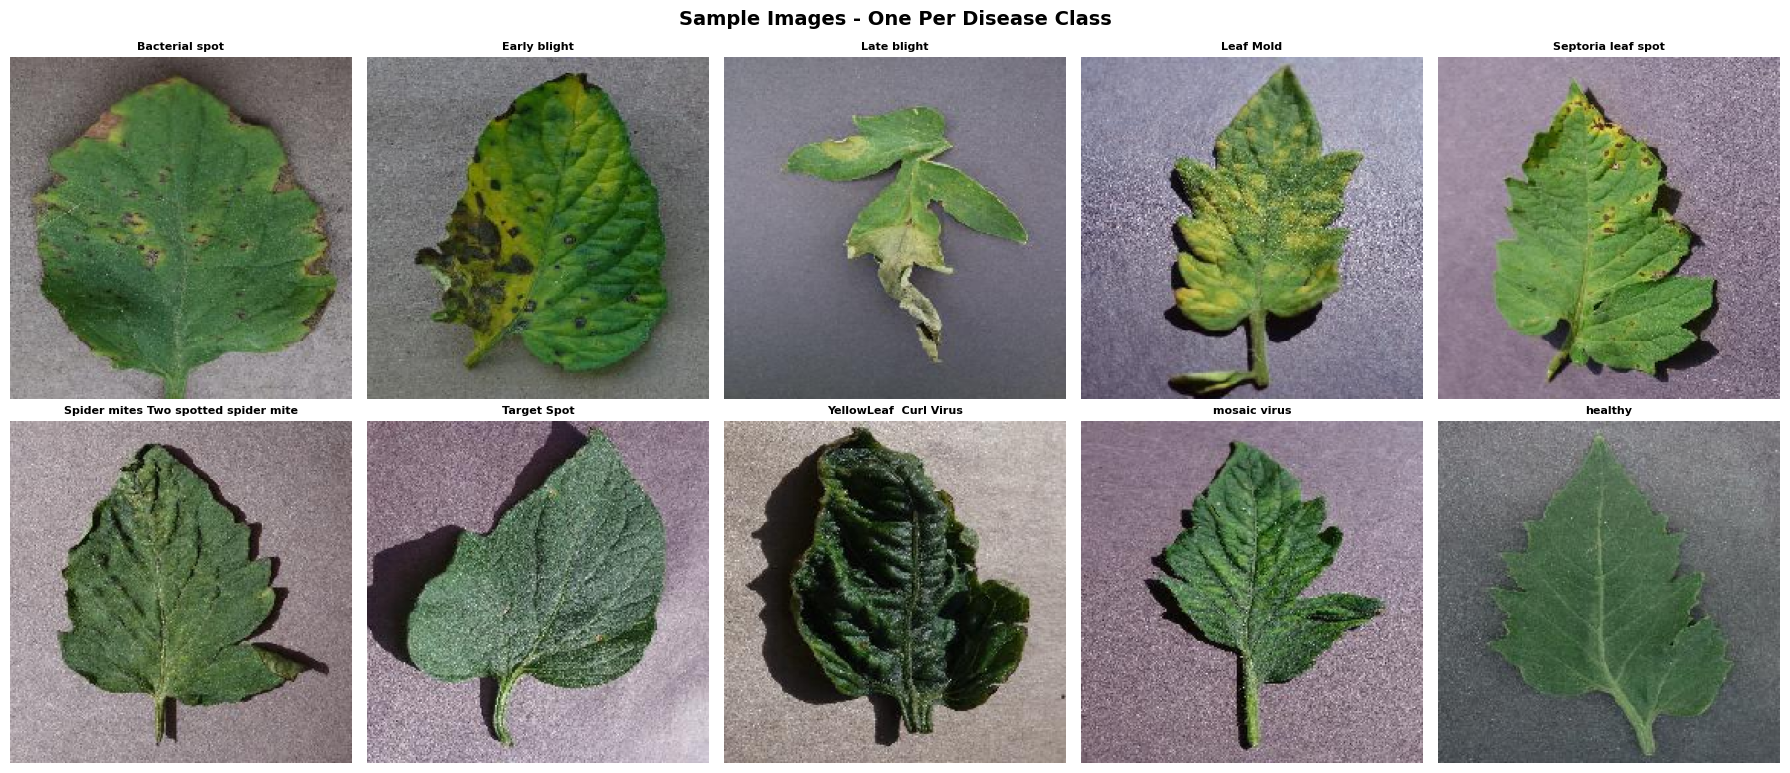

In [6]:
# Sample images from each class
classes_list = sorted(class_counts.keys())
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()
for i, cls in enumerate(classes_list[:10]):
    cls_path = os.path.join(dest_dir, cls)
    img_file = os.listdir(cls_path)[0]
    img = load_img(os.path.join(cls_path, img_file), target_size=(224, 224))
    axes[i].imshow(img)
    title = cls.replace('Tomato__','').replace('Tomato_','').replace('_',' ')
    axes[i].set_title(title, fontsize=8, fontweight='bold')
    axes[i].axis('off')
plt.suptitle('Sample Images - One Per Disease Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Train / Validation / Test Split (80 / 10 / 10)

In [7]:
import splitfolders

input_folder  = 'tomato_dataset_filtered'
output_folder = 'tomato_dataset_split'

if not os.path.exists(output_folder):
    print('Splitting dataset...')
    splitfolders.ratio(input_folder, output=output_folder,
                       seed=42, ratio=(.8, .1, .1), group_prefix=None)
    print('Split complete.')
else:
    print('Split already exists, skipping.')

for split in ['train', 'val', 'test']:
    sp = os.path.join(output_folder, split)
    total = sum(len(os.listdir(os.path.join(sp, c)))
                for c in os.listdir(sp) if os.path.isdir(os.path.join(sp, c)))
    print(f'  {split}: {total} images')


Splitting dataset...


Copying files: 16012 files [00:08, 1984.74 files/s]


Split complete.
  train: 12805 images
  val: 1597 images
  test: 1610 images


## 6. Data Augmentation & Generators

In [8]:
IMG_SIZE   = (224, 224)
IMG_SHAPE  = (224, 224, 3)
BATCH_SIZE = 32

base_split_dir = 'tomato_dataset_split'
train_dir = os.path.join(base_split_dir, 'train')
val_dir   = os.path.join(base_split_dir, 'val')
test_dir  = os.path.join(base_split_dir, 'test')

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical')

validation_generator = val_test_datagen.flow_from_directory(
    val_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)

test_generator = val_test_datagen.flow_from_directory(
    test_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)

class_names = list(train_generator.class_indices.keys())
num_classes = len(class_names)
print(f'Classes ({num_classes}): {class_names}')


Found 12804 images belonging to 10 classes.
Found 1597 images belonging to 10 classes.
Found 1610 images belonging to 10 classes.
Classes (10): ['Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


## 7. Build MobileNetV2 Transfer Learning Model
Architecture: `MobileNetV2 (frozen) → GlobalAveragePooling2D → Dropout(0.5) → Dense(num_classes, softmax)`

In [9]:
base_model = MobileNetV2(input_shape=IMG_SHAPE, include_top=False, weights='imagenet')
base_model.trainable = False

inputs  = Input(shape=IMG_SHAPE)
x       = base_model(inputs, training=False)
x       = GlobalAveragePooling2D()(x)
x       = Dropout(0.5)(x)
outputs = Dense(num_classes, activation='softmax')(x)
model   = Model(inputs, outputs)

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 8. Phase 1 - Train Classification Head (20 Epochs)
Only the custom top layers are trained. MobileNetV2 base is fully frozen.

**Callbacks:** `EarlyStopping` | `ModelCheckpoint` | `ReduceLROnPlateau`

In [10]:
EPOCHS = 20

callbacks_p1 = [
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_model_phase1.keras', monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-7, verbose=1)
]

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // BATCH_SIZE,
    callbacks=callbacks_p1
)


Epoch 1/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 479ms/step - accuracy: 0.4576 - loss: 1.6807
Epoch 1: val_accuracy improved from None to 0.77360, saving model to best_model_phase1.keras

Epoch 1: finished saving model to best_model_phase1.keras
400/400 ━━━━━━━━━━━━━━━━━━━━ 220s 500ms/step - accuracy: 0.5860 - loss: 1.2445 - val_accuracy: 0.7736 - val_loss: 0.6958 - learning_rate: 0.0010
Epoch 2/20
  1/400 ━━━━━━━━━━━━━━━━━━━━ 12s 31ms/step - accuracy: 0.7500 - loss: 0.7955

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy did not improve from 0.77360
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7500 - loss: 0.7955 - val_accuracy: 0.7730 - val_loss: 0.6976 - learning_rate: 0.0010
Epoch 3/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step - accuracy: 0.7197 - loss: 0.8253
Epoch 3: val_accuracy improved from 0.77360 to 0.80931, saving model to best_model_phase1.keras

Epoch 3: finished saving model to best_model_phase1.keras
400/400 ━━━━━━━━━━━━━━━━━━━━ 182s 454ms/step - accuracy: 0.7363 - loss: 0.7776 - val_accuracy: 0.8093 - val_loss: 0.5816 - learning_rate: 0.0010
Epoch 4/20
  1/400 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - accuracy: 0.7500 - loss: 0.5546
Epoch 4: val_accuracy improved from 0.80931 to 0.81250, saving model to best_model_phase1.keras

Epoch 4: finished saving model to best_model_phase1.keras
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7500 - loss: 0.5546 - val_accuracy: 0.8125 - val_loss: 0.5801 - learning_rate: 0.0010
Epoch 5/20
400/400 ━━━━━━━━━━━━━━━━

### Phase 1 Training Curves

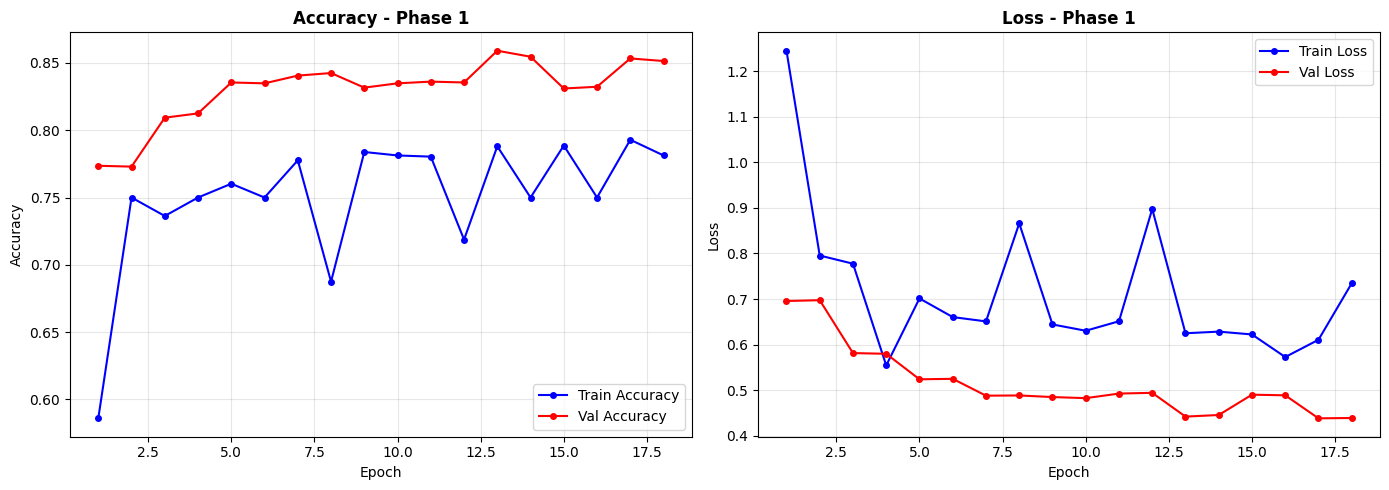

In [11]:
def plot_history(hist, title_suffix=''):
    acc      = hist.history['accuracy']
    val_acc  = hist.history['val_accuracy']
    loss     = hist.history['loss']
    val_loss = hist.history['val_loss']
    epochs   = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc,     'b-o', label='Train Accuracy', markersize=4)
    plt.plot(epochs, val_acc, 'r-o', label='Val Accuracy',   markersize=4)
    plt.title(f'Accuracy {title_suffix}', fontweight='bold')
    plt.xlabel('Epoch'); plt.ylabel('Accuracy')
    plt.legend(); plt.grid(alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss,     'b-o', label='Train Loss', markersize=4)
    plt.plot(epochs, val_loss, 'r-o', label='Val Loss',   markersize=4)
    plt.title(f'Loss {title_suffix}', fontweight='bold')
    plt.xlabel('Epoch'); plt.ylabel('Loss')
    plt.legend(); plt.grid(alpha=0.3)

    plt.tight_layout()
    fname = f'training_curves{title_suffix.replace(" ", "_")}.png'
    plt.savefig(fname, dpi=150)
    plt.show()

plot_history(history, '- Phase 1')


## 9. Phase 2 - Fine-Tuning (Unfreeze Top Layers)
Unfreeze MobileNetV2 layers after layer 100 and retrain with a very low learning rate (1e-5).

Trainable layers: 5
Epoch 19/28
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 478ms/step - accuracy: 0.4966 - loss: 2.3235
Epoch 19: val_accuracy improved from None to 0.85523, saving model to best_model_finetuned.keras

Epoch 19: finished saving model to best_model_finetuned.keras
400/400 ━━━━━━━━━━━━━━━━━━━━ 222s 501ms/step - accuracy: 0.6171 - loss: 1.4483 - val_accuracy: 0.8552 - val_loss: 0.4378 - learning_rate: 1.0000e-05
Epoch 20/28
  1/400 ━━━━━━━━━━━━━━━━━━━━ 17s 43ms/step - accuracy: 0.6562 - loss: 1.0469
Epoch 20: val_accuracy improved from 0.85523 to 0.85587, saving model to best_model_finetuned.keras

Epoch 20: finished saving model to best_model_finetuned.keras
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6562 - loss: 1.0469 - val_accuracy: 0.8559 - val_loss: 0.4375 - learning_rate: 1.0000e-05
Epoch 21/28
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 457ms/step - accuracy: 0.7379 - loss: 0.7356
Epoch 21: val_accuracy did not improve from 0.85587
400/400 ━━━━━━━━━━━━━━━━━━━━ 185s 464ms/step

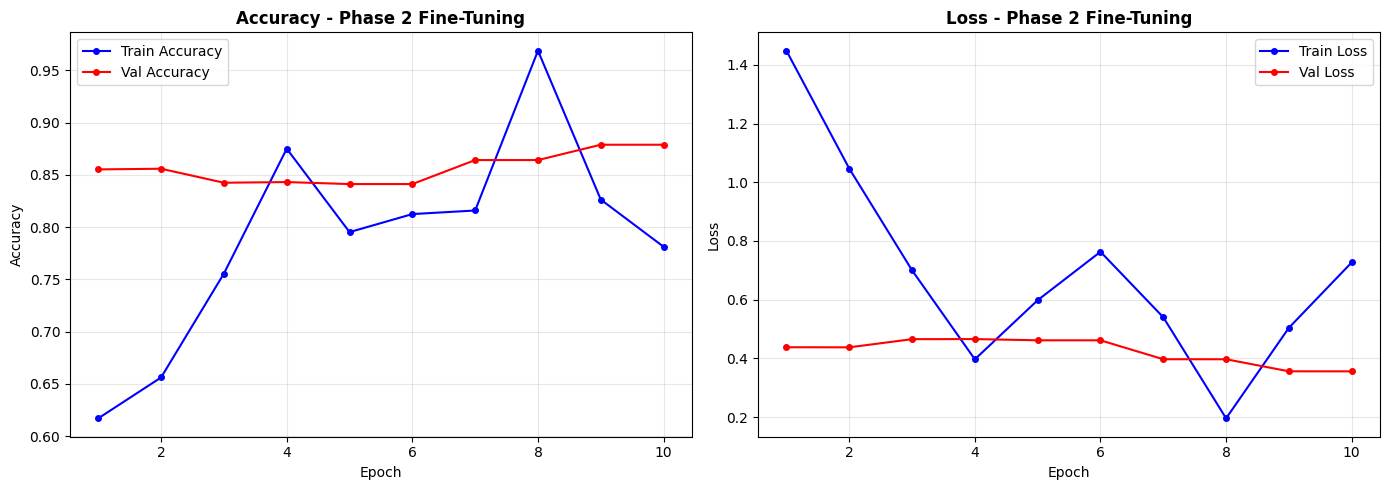

In [12]:
base_model.trainable = True
fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

print(f'Trainable layers: {sum(1 for l in model.layers if l.trainable)}')

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

FINE_TUNE_EPOCHS = 10
total_epochs = len(history.history['accuracy']) + FINE_TUNE_EPOCHS

callbacks_ft = [
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_model_finetuned.keras', monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-8, verbose=1)
]

history_fine = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=total_epochs,
    initial_epoch=len(history.history['accuracy']),
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // BATCH_SIZE,
    callbacks=callbacks_ft
)

plot_history(history_fine, '- Phase 2 Fine-Tuning')


## 10. Model Evaluation on Test Set

In [13]:
print('=== Test Set Evaluation ===')
test_loss, test_accuracy = model.evaluate(test_generator,
                                           steps=test_generator.samples // BATCH_SIZE)
print(f'Test Loss:     {test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy*100:.2f}%')


=== Test Set Evaluation ===
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.8825 - loss: 0.3362
Test Loss:     0.3362
Test Accuracy: 88.25%


51/51 ━━━━━━━━━━━━━━━━━━━━ 20s 289ms/step

=== Classification Report ===
                                      precision    recall  f1-score   support

                      Bacterial spot       0.92      0.91      0.91       214
                        Early blight       0.93      0.39      0.55       100
                         Late blight       0.90      0.91      0.90       192
                           Leaf Mold       0.82      0.93      0.87        96
                  Septoria leaf spot       0.84      0.93      0.88       178
Spider mites Two spotted spider mite       0.83      0.91      0.87       169
                         Target Spot       0.83      0.71      0.76       141
              YellowLeaf  Curl Virus       0.95      0.99      0.97       322
                        mosaic virus       0.82      0.95      0.88        38
                             healthy       0.88      0.96      0.92       160

                            accuracy                           0.88

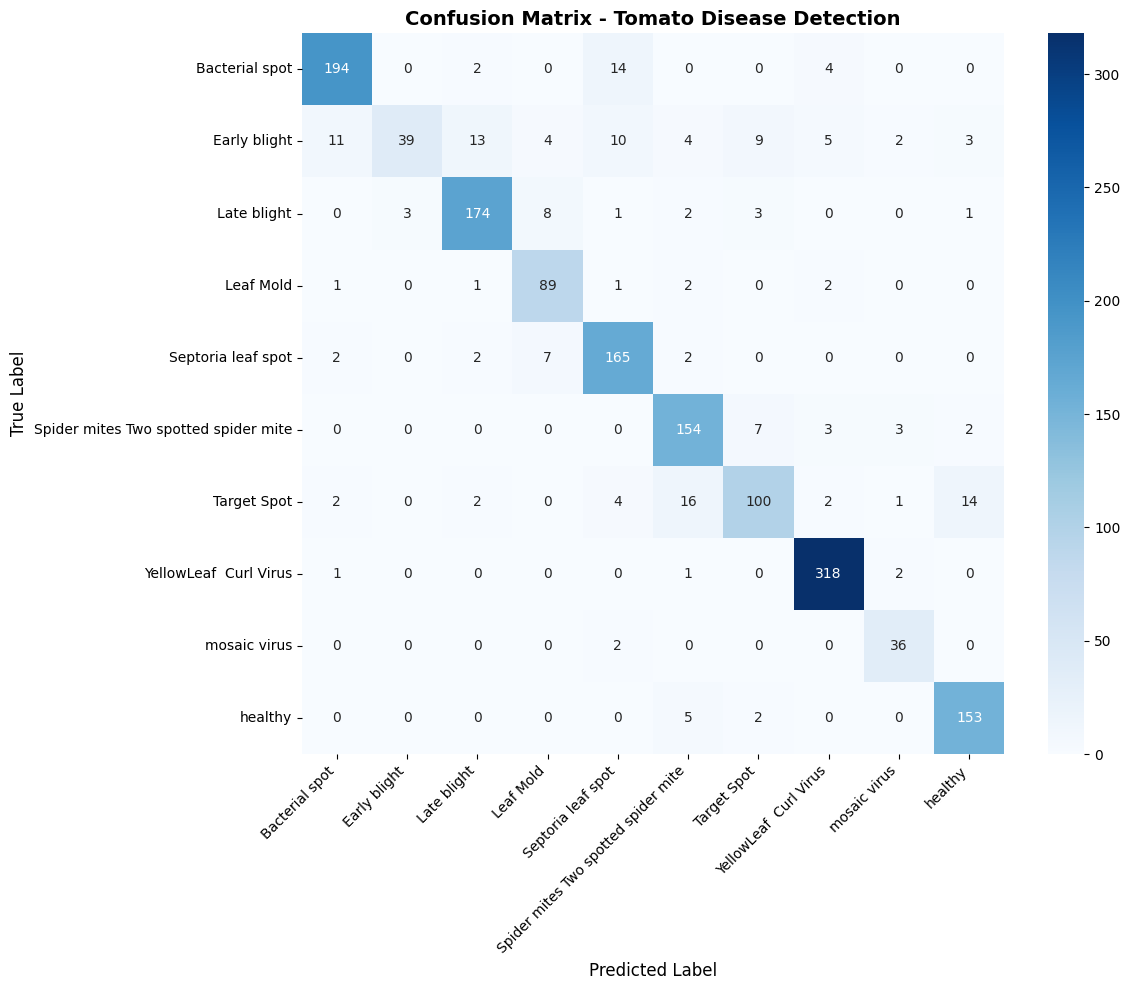

In [14]:
# Predictions & Reports
test_generator.reset()
predictions  = model.predict(test_generator, steps=test_generator.samples // BATCH_SIZE + 1)
pred_classes = np.argmax(predictions, axis=1)[:test_generator.samples]
true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())
display_labels = [l.replace('Tomato__','').replace('Tomato_','').replace('_',' ') for l in class_labels]

print('\n=== Classification Report ===')
print(classification_report(true_classes, pred_classes, target_names=display_labels))

cm = confusion_matrix(true_classes, pred_classes)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=display_labels, yticklabels=display_labels)
plt.title('Confusion Matrix - Tomato Disease Detection', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()


## 11. GradCAM - Model Interpretability
**GradCAM** highlights the leaf regions the model focused on when making its prediction, making the model explainable and trustworthy.

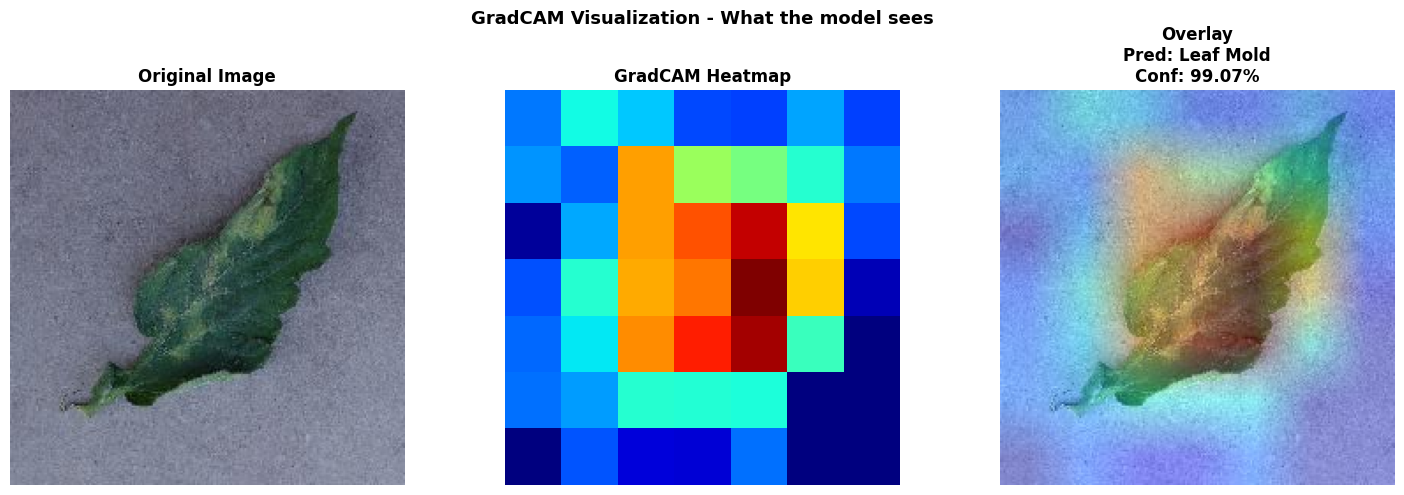

In [16]:
def make_gradcam_heatmap(img_array, model):
    # Get the MobileNetV2 base model layer
    base_model = model.get_layer('mobilenetv2_1.00_224')

    # Use the last conv layer inside the base model
    last_conv_layer = base_model.get_layer('Conv_1')

    # Build grad model going through base_model internals
    base_grad_model = Model(
        inputs=base_model.inputs,
        outputs=[last_conv_layer.output, base_model.output]
    )

    with tf.GradientTape() as tape:
        img_input = tf.cast(img_array, tf.float32)
        conv_outputs, base_out = base_grad_model(img_input)

        # Pass base output through the rest of the model (pooling, dropout, dense)
        x = model.get_layer('global_average_pooling2d')(base_out)
        x = model.get_layer('dropout')(x)
        predictions = model.get_layer('dense')(x)

        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = conv_outputs[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), int(pred_index), float(tf.reduce_max(predictions).numpy())


def display_gradcam(img_path, model, class_names):
    img = load_img(img_path, target_size=(224, 224))
    img_array = img_to_array(img) / 255.0
    img_input = np.expand_dims(img_array, axis=0)

    heatmap, pred_idx, confidence = make_gradcam_heatmap(img_input, model)

    heatmap_colored = cm_plt.jet(np.uint8(255 * heatmap))[:, :, :3]
    heatmap_resized = tf.image.resize(heatmap_colored, (224, 224)).numpy()
    superimposed    = np.clip(heatmap_resized * 0.4 + img_array, 0, 1)

    pred_label = class_names[pred_idx].replace('Tomato__','').replace('Tomato_','').replace('_',' ')

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img_array);            axes[0].set_title('Original Image',   fontweight='bold'); axes[0].axis('off')
    axes[1].imshow(heatmap, cmap='jet'); axes[1].set_title('GradCAM Heatmap', fontweight='bold'); axes[1].axis('off')
    axes[2].imshow(superimposed);         axes[2].set_title(f'Overlay\nPred: {pred_label}\nConf: {confidence:.2%}', fontweight='bold'); axes[2].axis('off')
    plt.suptitle('GradCAM Visualization - What the model sees', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('gradcam_output.png', dpi=150)
    plt.show()


# Run on a random test image
sample_class    = os.listdir(test_dir)[0]
sample_img_path = os.path.join(test_dir, sample_class, os.listdir(os.path.join(test_dir, sample_class))[0])
display_gradcam(sample_img_path, model, class_names)

## 12. Single Image Prediction
Use this function to predict the disease of any tomato leaf image.

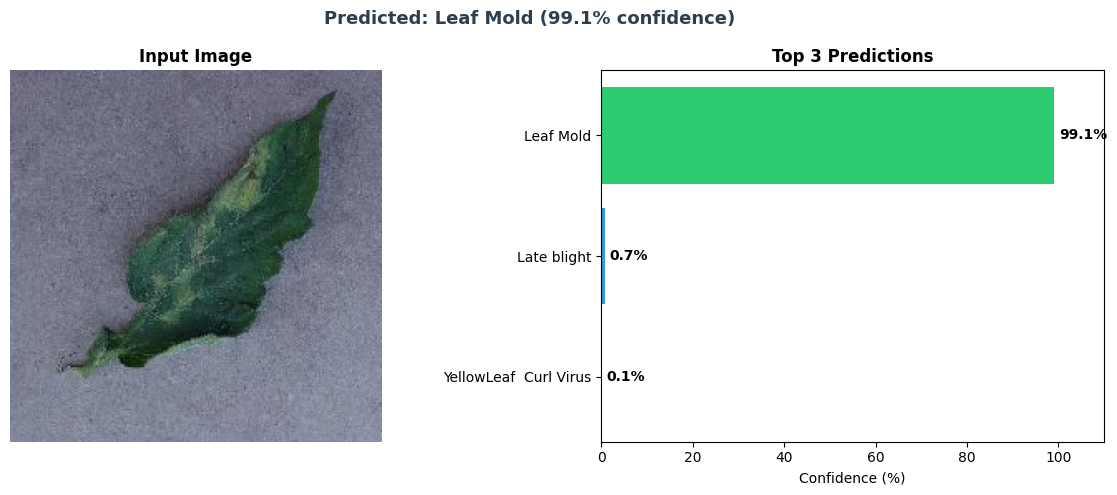


PREDICTION RESULT
  Leaf Mold                                99.07%
  Late blight                              0.71%
  YellowLeaf  Curl Virus                   0.08%


In [17]:
def predict_disease(img_path, model, class_names, top_k=3):
    img       = load_img(img_path, target_size=(224, 224))
    img_array = img_to_array(img) / 255.0
    img_input = np.expand_dims(img_array, axis=0)

    preds          = model.predict(img_input, verbose=0)[0]
    top_indices    = np.argsort(preds)[::-1][:top_k]
    top_labels     = [class_names[i].replace('Tomato__','').replace('Tomato_','').replace('_',' ') for i in top_indices]
    top_confs      = [preds[i] for i in top_indices]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(img_array)
    axes[0].set_title('Input Image', fontweight='bold')
    axes[0].axis('off')

    colors = ['#2ecc71'] + ['#3498db'] * (top_k - 1)
    bars = axes[1].barh(top_labels[::-1], [c*100 for c in top_confs[::-1]], color=colors[::-1])
    axes[1].set_xlabel('Confidence (%)')
    axes[1].set_title(f'Top {top_k} Predictions', fontweight='bold')
    axes[1].set_xlim(0, 110)
    for bar, conf in zip(bars, top_confs[::-1]):
        axes[1].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                     f'{conf*100:.1f}%', va='center', fontsize=10, fontweight='bold')

    plt.suptitle(f'Predicted: {top_labels[0]} ({top_confs[0]*100:.1f}% confidence)',
                 fontsize=13, fontweight='bold', color='#2c3e50')
    plt.tight_layout()
    plt.savefig('prediction_output.png', dpi=150)
    plt.show()

    print(f'\n{"="*45}')
    print('PREDICTION RESULT')
    print(f'{"="*45}')
    for label, conf in zip(top_labels, top_confs):
        print(f'  {label:<40} {conf*100:.2f}%')


# Test on the sample image
predict_disease(sample_img_path, model, class_names)


## 13. Save the Final Model

In [18]:
# Save in modern Keras format
model.save('tomato_disease_detector.keras')
print('Model saved as tomato_disease_detector.keras')

# Save class names
with open('class_names.json', 'w') as f:
    json.dump(class_names, f)
print('Class names saved as class_names.json')

# Download files from Colab
from google.colab import files
files.download('tomato_disease_detector.keras')
files.download('class_names.json')


Model saved as tomato_disease_detector.keras
Class names saved as class_names.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 14. Project Summary

| Component | Detail |
|-----------|--------|
| **Model** | MobileNetV2 (Transfer Learning + Fine-Tuning) |
| **Dataset** | PlantVillage — Tomato Classes (Kaggle) |
| **Classes** | 10 tomato disease categories |
| **Input Size** | 224 x 224 x 3 |
| **Augmentation** | Rotation, Flip, Zoom, Brightness, Shear, Shift |
| **Callbacks** | EarlyStopping, ModelCheckpoint, ReduceLROnPlateau |
| **Interpretability** | GradCAM Visualization |
| **Output** | Disease class + top-3 confidence scores |

### Skills Demonstrated
- Deep Learning & Transfer Learning (MobileNetV2 / ImageNet)
- Image Classification with Data Augmentation
- Two-phase Training: Feature Extraction + Fine-Tuning
- Model Evaluation: Accuracy, F1-Score, Confusion Matrix
- GradCAM Explainability / Model Interpretability
- Python | TensorFlow/Keras | Matplotlib | Seaborn | Scikit-learn
